In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from test_schwefel.schwefel_function import schwefel3D,schwefel3D_numpy
from connectivity.connectivity import trace_connectivity, extract_connection_indices, save_descent_paths
from connectivity.saddle_tree_calculations import saddle_tree_calculations
from connectivity.plot_results import plot_results_with_paths_3d

In [2]:
dataframe = pd.read_csv("test_schwefel/critical_points_schwefel_3D.csv")
saddles_df = dataframe[dataframe["type"] == "saddle"]
minima_df = dataframe[dataframe["type"] == "minimum"]
func = lambda x: schwefel3D(x[0], x[1], x[2])

In [3]:
all_results, minima, dataframe, paths = trace_connectivity(
    saddles_df, minima_df, dataframe ,func, return_paths=True
)

In [4]:
save_descent_paths(paths)
extract_connection_indices(all_results, dataframe)

3
Saved 115 connections to results/saddle_to_minima_indices3D.csv


/var/folders/87/h8fnyth55477f11hgmy38l4h0000gn/T/ipykernel_76625/3999758709.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


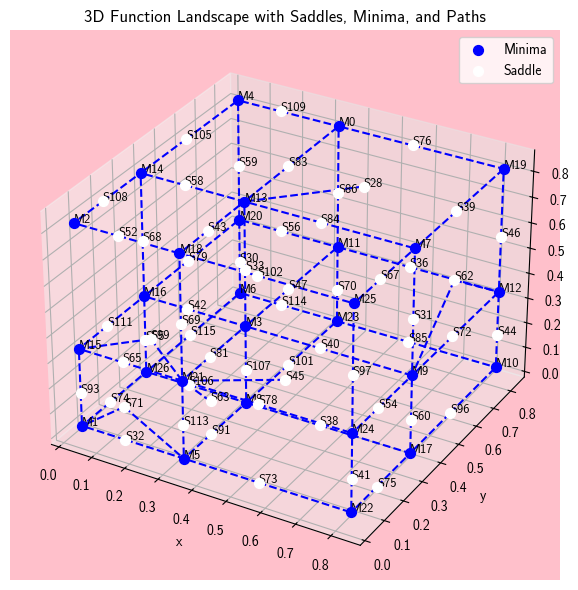

In [2]:
fig2 = plt.figure(figsize=(6, 6))

fig2 = plot_results_with_paths_3d(func=schwefel3D_numpy,  
                                critical_points_csv="test_schwefel/critical_points_schwefel_3d.csv",
                                saddle_to_minima_csv="results/saddle_to_minima_indices3D.csv",      
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)
fig2.show()
fig2.savefig("plots/landscape_paths_3D.png")  # Optional